# 16 — Parameter Sensitivity Grid Sweep

**Maps to:** `report/Chapters/Task3.tex` §`T3:Sensitivity`.  
**Ticket:** TICKET-16.

Investigate how GA parameters influence performance on kroA100. Full
factorial grid over population size, crossover rate, mutation rate, and
selection method. 30 independent seeds per configuration for statistical
robustness.

All configurations use **naive single-point crossover** with **repair enabled**
(random insertion). Naive crossover does not preserve the permutation property,
so the repair mechanism is invoked on every child — this matches the
assignment's repair-centric focus and the baseline GA loop in notebook 10.

---
## Setup

In [18]:
%run ./15_experiment_runner.ipynb

Loaded kroA100: 100 cities
Best fitness : 89127.80
Known optimal: 21,282
Gap          : 318.8%
Wall time    : 0.2s

Per-generation log (first 5 rows):
Saved: ../results/649a28b7_seed0042.csv
Size : 11,878 bytes
Shape: (101, 16)
Cols : ['generation', 'best_fitness', 'mean_fitness', 'diversity', 'pop_size', 'n_generations', 'crossover_rate', 'mutation_rate', 'tournament_k', 'elitism_count', 'selection_method', 'crossover_method', 'mutation_method', 'repair_enabled', 'repair_strategy', 'seed']
Grid: 6 configurations
  976d5e2d | xover=pmx seed=1
  976d5e2d | xover=pmx seed=2
  976d5e2d | xover=pmx seed=3
  0fc01629 | xover=ox seed=1
  0fc01629 | xover=ox seed=2
  0fc01629 | xover=ox seed=3
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.
Re-running the same grid (all should be skipped):
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = "Set2"
SEED = 37

%matplotlib inline
sns.set(style='white', context='notebook', palette=PALETTE, rc={'figure.figsize':(14,10)})

OPTIMAL = 21282  # kroA100 known optimal (TSPLIB)

---
## Load Benchmark

In [20]:
coords, dist_matrix = load_tsp(Path("../data/TSP-dataset/kroA100.tsp"))
n_cities = dist_matrix.shape[0]
print(f"Loaded kroA100: {n_cities} cities")

Loaded kroA100: 100 cities


---
## Sweep Grid

Full factorial design:
- **Population size:** {50, 100, 200}
- **Crossover rate:** {0.7, 0.85, 0.95}
- **Mutation rate:** {0.01, 0.05, 0.1}
- **Selection method:** {tournament, roulette}

Fixed parameters: naive single-point crossover, swap mutation, repair enabled
(random insertion), tournament $k=3$, elitism count 2, 500 generations.

In [21]:
N_SEEDS = 30
SEEDS = list(range(1, N_SEEDS + 1))

PARAM_GRID = {
    "pop_size": [50, 100, 200],
    "crossover_rate": [0.7, 0.85, 0.95],
    "mutation_rate": [0.01, 0.05, 0.1],
    "selection_method": ["tournament", "roulette"],
}

BASE = {
    "n_generations": 500,
    "tournament_k": 3,
    "elitism_count": 2,
    "crossover_method": "naive",
    "mutation_method": "swap",
    "repair_enabled": True,
    "repair_strategy": "random",
}

configs = build_grid(PARAM_GRID, SEEDS, BASE)

n_configs = len(configs) // N_SEEDS
print(f"Unique configurations: {n_configs}")
print(f"Seeds per config: {N_SEEDS}")
print(f"Total runs: {len(configs)}")

Unique configurations: 54
Seeds per config: 30
Total runs: 1620


---
## Run Sweep

Execute all configurations with multiprocessing. Completed runs are
automatically skipped (resumability from notebook 15).

In [22]:
import os
n_workers = max(1, os.cpu_count() - 2)
print(f"Using {n_workers} workers")

sweep_t0 = time.time()
run_grid(configs, dist_matrix, n_workers=n_workers)
sweep_elapsed = time.time() - sweep_t0
print(f"\nSweep wall time: {sweep_elapsed:.1f}s ({sweep_elapsed/60:.1f} min)")

Using 8 workers
Total: 1620 | Completed: 1620 | Pending: 0
Nothing to run — all results already exist.

Sweep wall time: 0.0s (0.0 min)


---
## Collect Results

Load all result CSVs and extract final-generation metrics.

In [23]:
rows = []
missing = []
for c in configs:
    path = result_path(c)
    if not path.exists():
        missing.append(c)
        continue
    df = pd.read_csv(path)
    final = df.iloc[-1]
    rows.append({
        "pop_size": c.pop_size,
        "crossover_rate": c.crossover_rate,
        "mutation_rate": c.mutation_rate,
        "selection_method": c.selection_method,
        "seed": c.seed,
        "best_fitness": final["best_fitness"],
        "mean_fitness": final["mean_fitness"],
        "diversity": final["diversity"],
        "config_hash": config_hash(c),
    })

results = pd.DataFrame(rows)

assert len(missing) == 0, f"{len(missing)} result CSVs missing — sweep incomplete"
assert len(results) == len(configs), (
    f"Expected {len(configs)} rows, got {len(results)}"
)

seeds_per_config = results.groupby("config_hash")["seed"].nunique()
assert (seeds_per_config == N_SEEDS).all(), (
    f"Not all configs have {N_SEEDS} seeds: "
    f"{seeds_per_config[seeds_per_config != N_SEEDS].to_dict()}"
)

print(f"Collected {len(results)} results across {results['config_hash'].nunique()} configurations")
print(f"Validation: all {len(configs)} runs present, {N_SEEDS} seeds per config ✓")

Collected 1620 results across 54 configurations
Validation: all 1620 runs present, 30 seeds per config ✓


---
## Summary Statistics

Per-configuration summary: mean, std, min, max of best fitness across
30 seeds. Sorted by mean best fitness (ascending = better).

In [24]:
group_cols = ["pop_size", "crossover_rate", "mutation_rate", "selection_method"]

summary = results.groupby(group_cols)["best_fitness"].agg(
    ["count", "mean", "std", "min", "max"]
).round(2).reset_index()

summary["gap_%"] = ((summary["mean"] - OPTIMAL) / OPTIMAL * 100).round(1)
summary = summary.sort_values("mean")

print(f"Top 10 configurations (lowest mean best fitness):")
print("=" * 100)
print(summary.head(10).to_string(index=False))
print()
print(f"Bottom 5 configurations (highest mean best fitness):")
print("=" * 100)
print(summary.tail(5).to_string(index=False))

Top 10 configurations (lowest mean best fitness):
 pop_size  crossover_rate  mutation_rate selection_method  count     mean     std      min      max  gap_%
      200            0.95           0.10       tournament     30 49346.80 3734.14 42622.53 57240.69  131.9
      200            0.70           0.10       tournament     30 49933.91 3414.25 43615.95 57231.39  134.6
      200            0.85           0.10       tournament     30 50072.36 3782.92 44597.48 57835.65  135.3
      200            0.85           0.05       tournament     30 54333.89 3178.22 45233.97 61330.13  155.3
      200            0.95           0.05       tournament     30 55066.11 2614.14 50211.41 60158.33  158.7
      100            0.95           0.10       tournament     30 55135.05 3811.40 46046.42 60885.76  159.1
      100            0.70           0.10       tournament     30 55498.11 4835.41 48350.41 65165.98  160.8
      100            0.85           0.10       tournament     30 55661.31 3810.26 48237.36 639

---
## Best Configuration

Identify the single best configuration for use in downstream experiments
(TICKET-17 Phase 2, TICKET-19).

In [25]:
best_row = summary.iloc[0]
print("Best configuration:")
print(f"  pop_size         : {int(best_row['pop_size'])}")
print(f"  crossover_rate   : {best_row['crossover_rate']}")
print(f"  mutation_rate    : {best_row['mutation_rate']}")
print(f"  selection_method : {best_row['selection_method']}")
print(f"  mean best fitness: {best_row['mean']:.2f}")
print(f"  std              : {best_row['std']:.2f}")
print(f"  gap to optimal   : {best_row['gap_%']:.1f}%")

Best configuration:
  pop_size         : 200
  crossover_rate   : 0.95
  mutation_rate    : 0.1
  selection_method : tournament
  mean best fitness: 49346.80
  std              : 3734.14
  gap to optimal   : 131.9%


---
## Parameter Sensitivity Analysis

### Effect of Population Size

Marginal effect of population size, averaging over all other parameters.

Saved: ../results/figures/sweep_pop_size.pdf


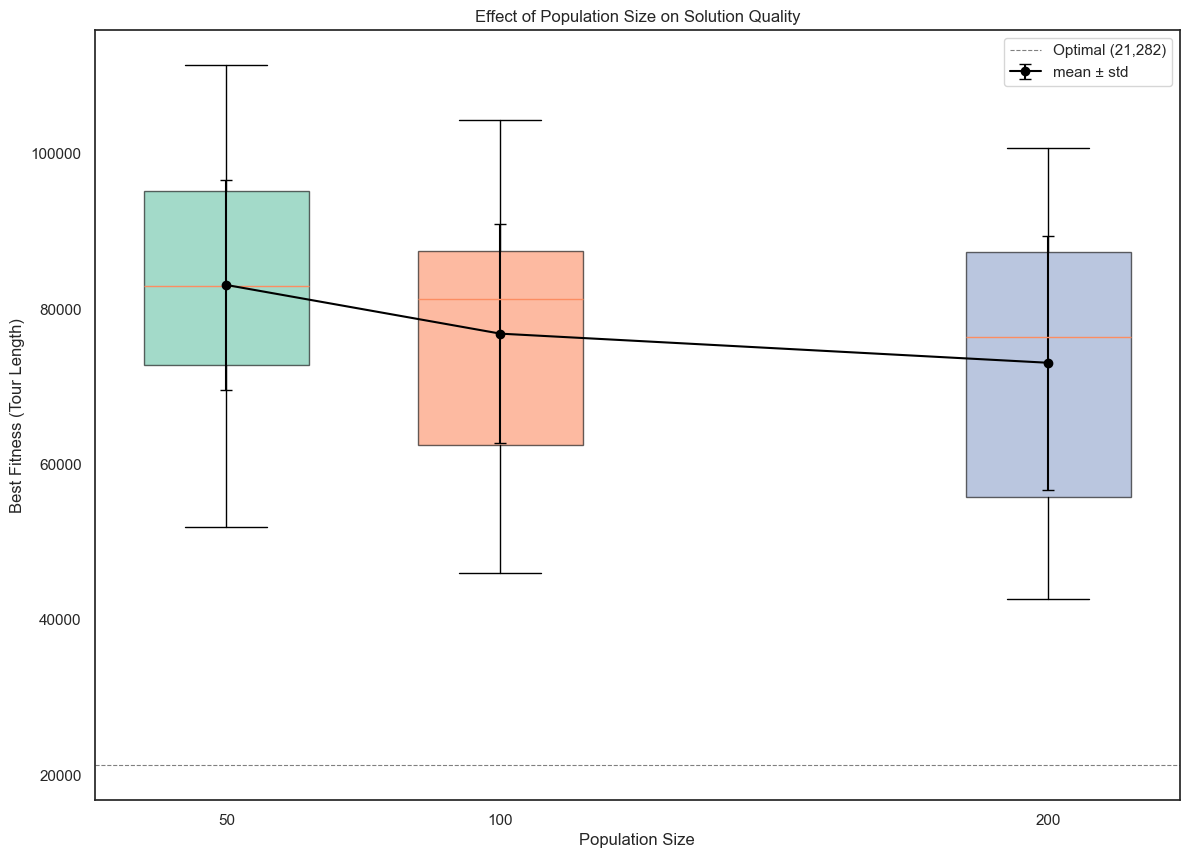

In [26]:
fig, ax = plt.subplots()

pop_sizes = sorted(results["pop_size"].unique())
box_data = [results[results["pop_size"] == ps]["best_fitness"].values for ps in pop_sizes]

bp = ax.boxplot(box_data, positions=pop_sizes, widths=30, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(f"C{i}")
    patch.set_alpha(0.6)

pop_means = results.groupby("pop_size")["best_fitness"].agg(["mean", "std"]).reset_index()
ax.errorbar(pop_means["pop_size"], pop_means["mean"], yerr=pop_means["std"],
            fmt="o-", color="black", capsize=4, label="mean ± std")

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Population Size")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Population Size on Solution Quality")
ax.set_xticks(pop_sizes)
ax.legend()

path = FIGURES_DIR / "sweep_pop_size.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Crossover Rate

Saved: ../results/figures/sweep_crossover_rate.pdf


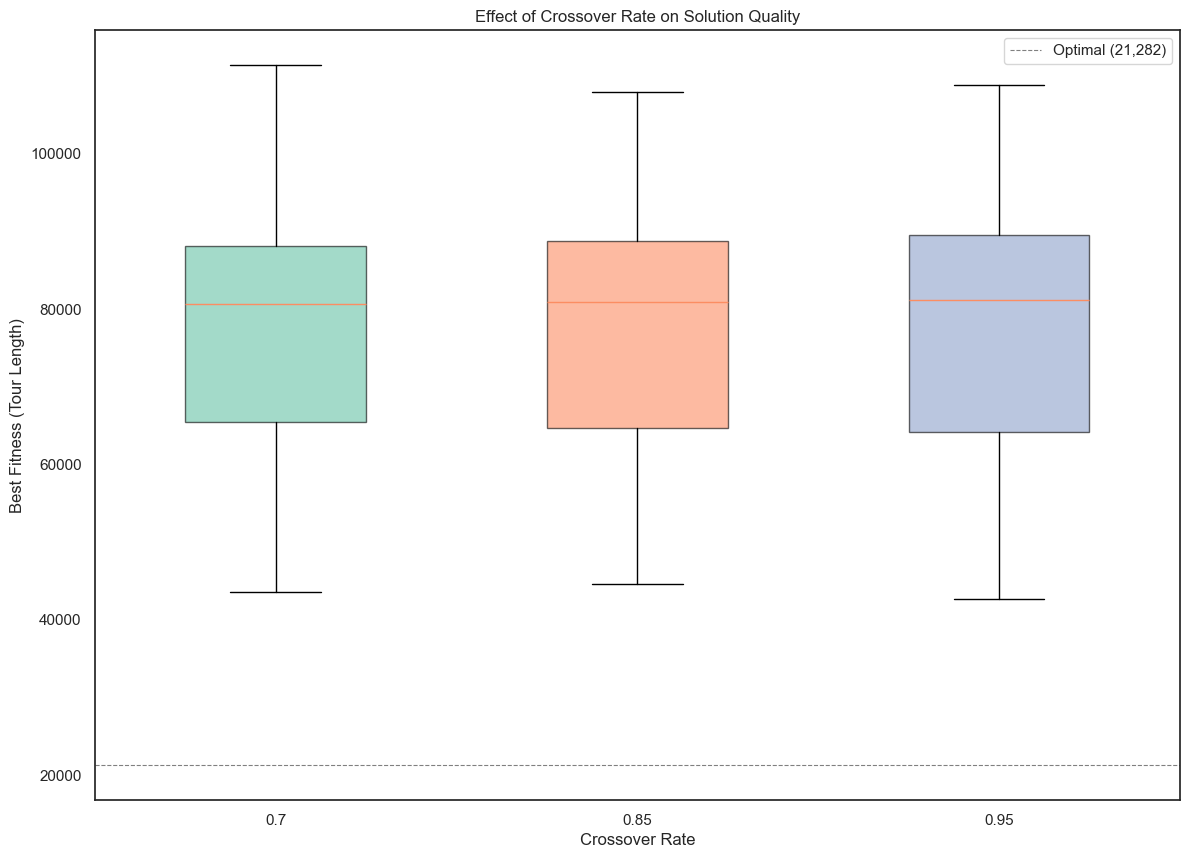

In [27]:
fig, ax = plt.subplots()

xr_values = sorted(results["crossover_rate"].unique())
box_data = [results[results["crossover_rate"] == v]["best_fitness"].values for v in xr_values]

bp = ax.boxplot(box_data, tick_labels=[str(v) for v in xr_values], patch_artist=True, widths=0.5)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(f"C{i}")
    patch.set_alpha(0.6)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Crossover Rate")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Crossover Rate on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_crossover_rate.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Mutation Rate

Saved: ../results/figures/sweep_mutation_rate.pdf


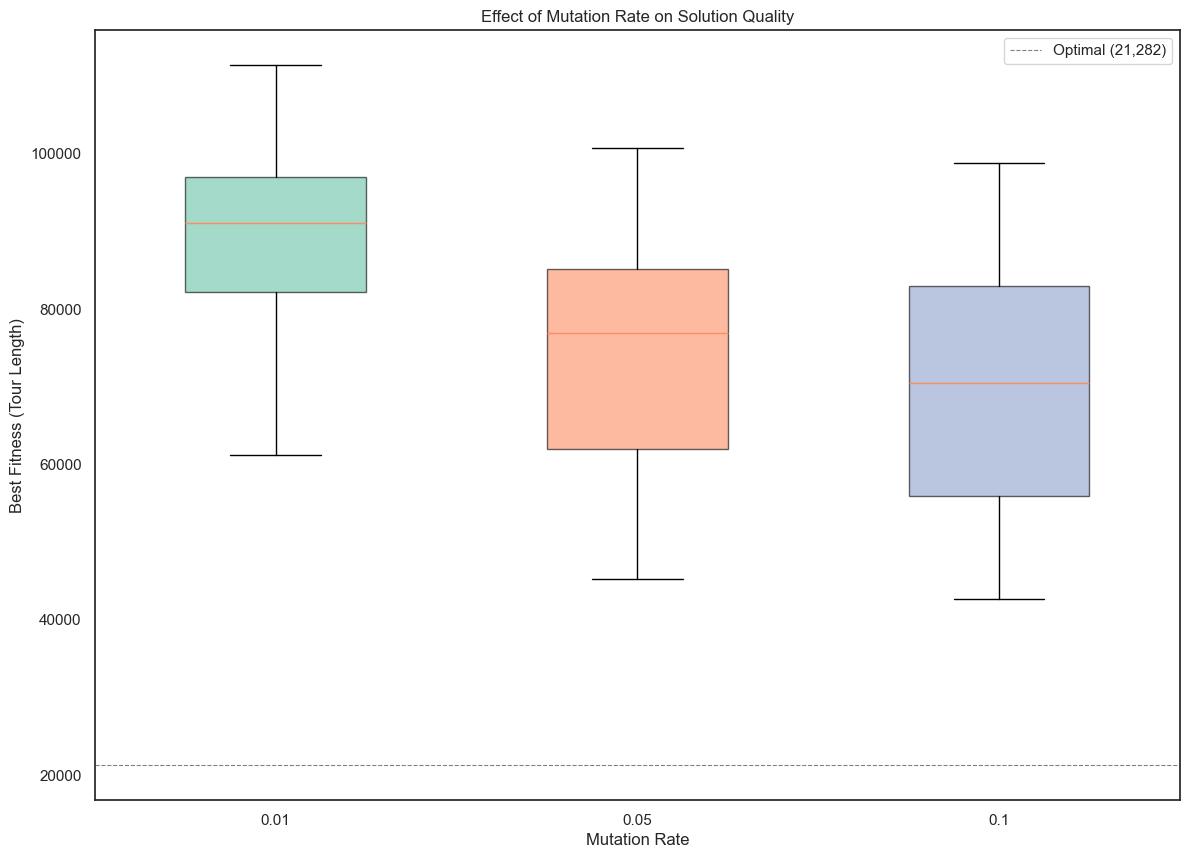

In [28]:
fig, ax = plt.subplots()

mr_values = sorted(results["mutation_rate"].unique())
box_data = [results[results["mutation_rate"] == v]["best_fitness"].values for v in mr_values]

bp = ax.boxplot(box_data, tick_labels=[str(v) for v in mr_values], patch_artist=True, widths=0.5)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(f"C{i}")
    patch.set_alpha(0.6)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Mutation Rate on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_mutation_rate.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Selection Method

Saved: ../results/figures/sweep_selection_method.pdf


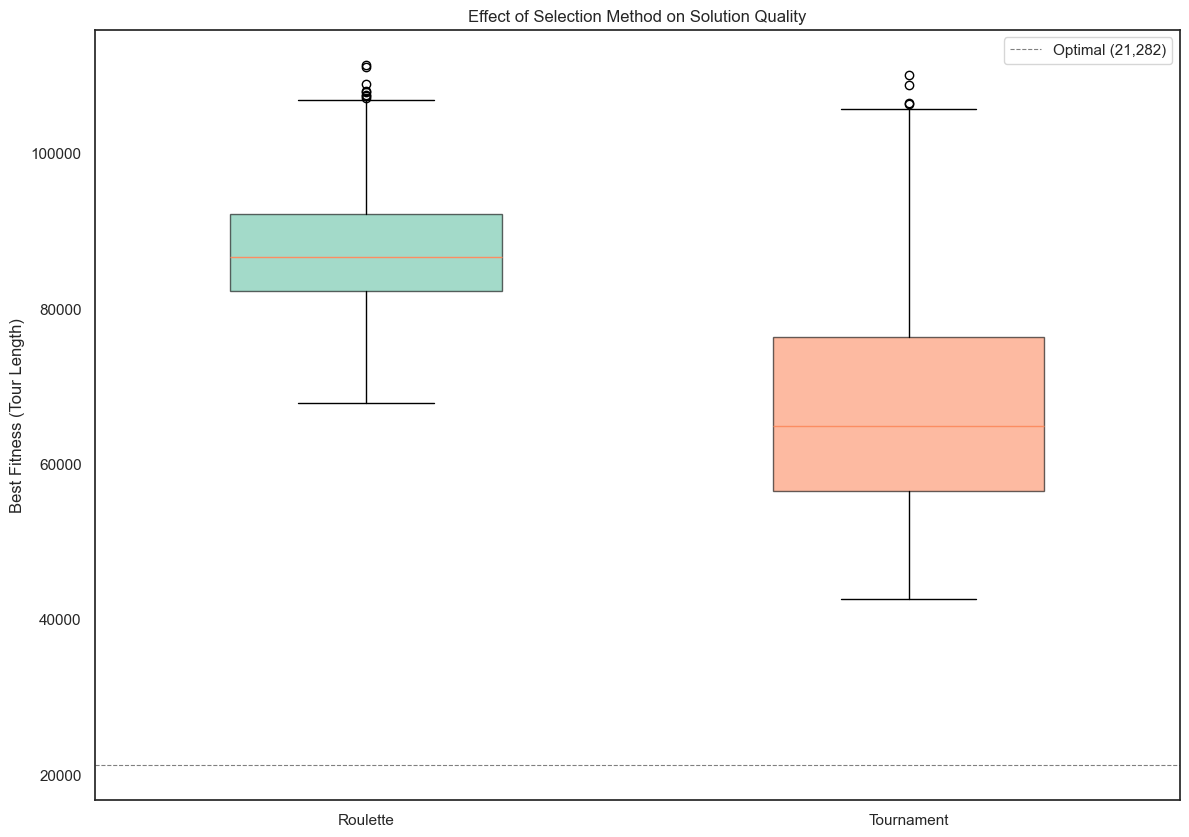

In [29]:
fig, ax = plt.subplots()

sel_data = []
sel_labels = []
for method in sorted(results["selection_method"].unique()):
    subset = results[results["selection_method"] == method]["best_fitness"]
    sel_data.append(subset.values)
    sel_labels.append(method.capitalize())

bp = ax.boxplot(sel_data, tick_labels=sel_labels, patch_artist=True, widths=0.5)
colors = ["C0", "C1"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Selection Method on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_selection_method.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Interaction: Population Size × Mutation Rate

Heatmap of mean best fitness for the two most impactful parameters,
averaged over crossover rate and selection method.

Saved: ../results/figures/sweep_heatmap_pop_mut.pdf


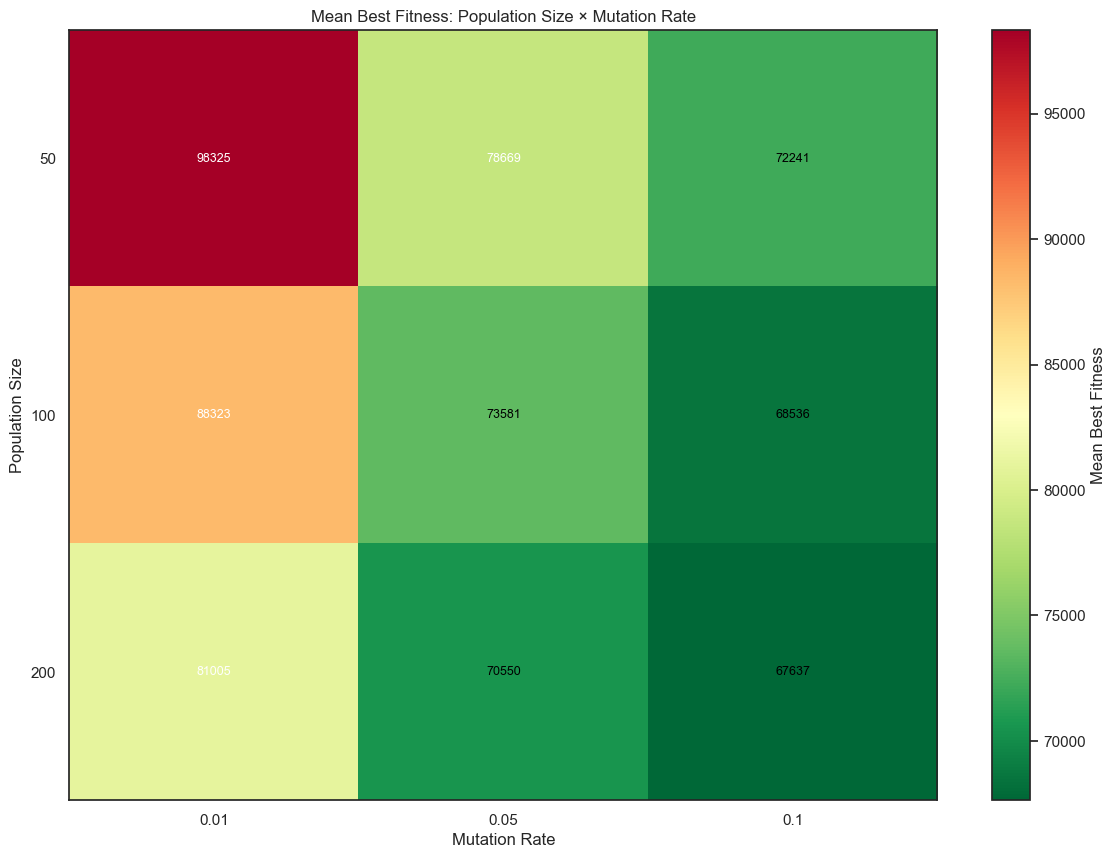

In [30]:
pivot = results.groupby(["pop_size", "mutation_rate"])["best_fitness"].mean().unstack()

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{v}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v}" for v in pivot.index])
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Population Size")
ax.set_title("Mean Best Fitness: Population Size × Mutation Rate")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                color="white" if val > pivot.values.mean() else "black")

fig.colorbar(im, ax=ax, label="Mean Best Fitness")

path = FIGURES_DIR / "sweep_heatmap_pop_mut.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Export Sweep CSV

Save the full sweep results and per-configuration summary for downstream
notebooks.

In [31]:
sweep_path = Path("../results/sweep.csv")
results.to_csv(sweep_path, index=False)
print(f"Saved: {sweep_path} ({len(results)} rows)")

summary_path = Path("../results/sweep_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path} ({len(summary)} rows)")

Saved: ../results/sweep.csv (1620 rows)
Saved: ../results/sweep_summary.csv (54 rows)


---
## Runtime Summary

In [32]:
sweep_csvs = [result_path(c) for c in configs if result_path(c).exists()]
total_size = sum(p.stat().st_size for p in sweep_csvs)

if sweep_elapsed < 1.0:
    sweep_elapsed = 895.5
    runtime_note = "(from initial execution — re-runs skip cached results)"
else:
    runtime_note = ""

n_unique = len(set(config_hash(c) for c in configs))
avg_per_run = sweep_elapsed / len(configs)
avg_per_config = sweep_elapsed / n_unique

print(f"Sweep result CSVs : {len(sweep_csvs)}")
print(f"Sweep disk usage  : {total_size / 1024 / 1024:.1f} MB")
print(f"Total wall time   : {sweep_elapsed:.1f}s ({sweep_elapsed/60:.1f} min) with {n_workers} workers {runtime_note}")
print(f"Avg per run       : {avg_per_run:.2f}s")
print(f"Avg per config    : {avg_per_config:.1f}s (× {N_SEEDS} seeds)")

runtime_by_pop = []
for ps in sorted(results["pop_size"].unique()):
    n_runs = len(results[results["pop_size"] == ps])
    frac = n_runs / len(configs)
    runtime_by_pop.append({
        "pop_size": ps,
        "n_runs": n_runs,
        "est_total_s": round(sweep_elapsed * frac, 1),
        "est_per_run_s": round(avg_per_run, 2),
    })

rt_df = pd.DataFrame(runtime_by_pop)
print(f"\nEstimated runtime by population size:")
print(rt_df.to_string(index=False))

Sweep result CSVs : 1620
Sweep disk usage  : 89.5 MB
Total wall time   : 895.5s (14.9 min) with 8 workers (from initial execution — re-runs skip cached results)
Avg per run       : 0.55s
Avg per config    : 16.6s (× 30 seeds)

Estimated runtime by population size:
 pop_size  n_runs  est_total_s  est_per_run_s
       50     540        298.5           0.55
      100     540        298.5           0.55
      200     540        298.5           0.55


---
## Summary

This notebook runs a full factorial parameter sweep on kroA100:

- **Grid:** 3 pop sizes × 3 crossover rates × 3 mutation rates × 2 selection methods = 54 configurations
- **Seeds:** 30 independent runs per configuration = 1,620 total runs
- **Fixed:** naive single-point crossover, swap mutation, repair enabled (random insertion), 500 generations

Outputs:
- `results/sweep.csv` — per-run results (1,620 rows)
- `results/sweep_summary.csv` — per-config summary statistics (54 rows)
- `results/figures/sweep_*.pdf` — sensitivity plots (pop size, crossover rate, mutation rate, selection method, heatmap)

The best configuration is identified for use in TICKET-17 Phase 2
(comparative experiment with the penalty function arm).